In [1]:
# Importing necessary libraries
# General Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# ML library
from sklearn import model_selection
from sklearn import linear_model
from sklearn import metrics
from sklearn import linear_model

# Data Balancing Library
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

# regression-multiple-methods.ipynb

import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Loading Data and Data Summary

In [2]:
metric_table = pd.DataFrame()
# Algorithms

algorithms = {
        'Linear Regression': LinearRegression(),
        'SVM Regression': SVR(kernel='poly'),  # Adjust kernel as needed
        'RandomForest': RandomForestRegressor(),
        'XGBoost': GradientBoostingRegressor(),
        'knn': KNeighborsRegressor(),
        'Neural Network-10': MLPRegressor(hidden_layer_sizes=[10], max_iter=20000),
    }
file_path = 'curse-of-dimensionality.xlsx'
np.random.seed(42)
# load the dataset
xls = pd.ExcelFile(file_path)

In [3]:
def trainAndTestWithSampling(X, y, strategy, use_strag, model, model_name):
  np.random.seed(5)
  # split into train/test sets with same class ratio
  trainX, testX, trainy, testy = model_selection.train_test_split(X, y, test_size=0.2,random_state=42)

  #Apply sampling technique if any
  if use_strag:
    trainX, trainy = strategy.fit_resample(trainX, trainy)
  # define model
  # fit model
  model.fit(trainX, trainy)
  # predict on test set
  yhat = model.predict(trainX)
  # evaluate predictions
  r2_train = model.score(trainX, trainy)
  rmse_train = root_mean_squared_error(trainy, yhat)
  residuals_train = trainy - yhat
  
  # predict on test set
  yhat_test = model.predict(testX)
  # evaluate predictions
  r2_test = model.score(testX, testy)
  rmse_test = root_mean_squared_error(testy, yhat_test)
  residuals_test = testy - yhat_test
  metric_table.at[model_name, 'R-squared Train'] = r2_train
  metric_table.at[model_name, 'RMSE Train'] = rmse_train
  metric_table.at[model_name, 'R-squared Test'] = r2_test
  metric_table.at[model_name, 'RMSE Test'] = rmse_test
  return trainX, testX, trainy, testy,r2_train,rmse_train,r2_test,rmse_test

In [4]:
def calculate_vif(dataframe):
    vif_data = pd.DataFrame()
    vif_data["feature"] = dataframe.columns
    # calculating VIF for each feature
    vif_data["VIF"] = [variance_inflation_factor(dataframe.values, i) for i in range(len(dataframe.columns))]
    return vif_data

In [5]:
# 2. Iterative VIF Reduction Loop
vif_threshold = 5.0 # Set your desired threshold

def progressive_vif_analysis(X_current, X_test_current, trainy, testy, algorithm, model_name):
    dropped_features = []
    metrics_history = pd.DataFrame()
    while True:
        vif_results = calculate_vif(X_current)
        # Exclude the intercept from VIF check for dropping features
        highest_vif_feature = vif_results[vif_results['feature'] != 'intercept'].sort_values(by='VIF', ascending=False).iloc[0]
        
        if highest_vif_feature['VIF'] > vif_threshold:
            feature_to_drop = highest_vif_feature['feature']
            dropped_features.append(feature_to_drop)
            print(f"Dropping '{feature_to_drop}' (VIF: {highest_vif_feature['VIF']:.2f})")
            # Drop the feature from both train and test sets
            X_current = X_current.drop(columns=feature_to_drop)
            X_test_current = X_test_current.drop(columns=feature_to_drop)
            # Train model and record metrics *after* the drop
            trainX_progressive_vif, testX_progressive_vif, trainy_progressive_vif, testy_progressive_vif,r2_train,rmse_train,r2_test,rmse_test = trainAndTestWithSampling(X_current, trainy,False,False, algorithm, model_name)
            metrics_history.at[feature_to_drop, 'R-squared Train'] = r2_train
            metrics_history.at[feature_to_drop, 'RMSE Train'] = rmse_train
            metrics_history.at[feature_to_drop, 'R-squared Test'] = r2_test
            metrics_history.at[feature_to_drop, 'RMSE Test'] = rmse_test
        else:
            print(f"\nAll remaining features have VIF below threshold of {vif_threshold}.")
            break   
    print("------------------- progressive_vif_analysis ------------------------------")     
    print(f'ALGORITHM {model_name}')
    print(f'Total dropped features are {dropped_features} ')   
    print(f'Metrics History\n {metrics_history.to_string()}')  
    print("------------------- progressive_vif_analysis ------------------------------")           

## VIF Program Starting Here!

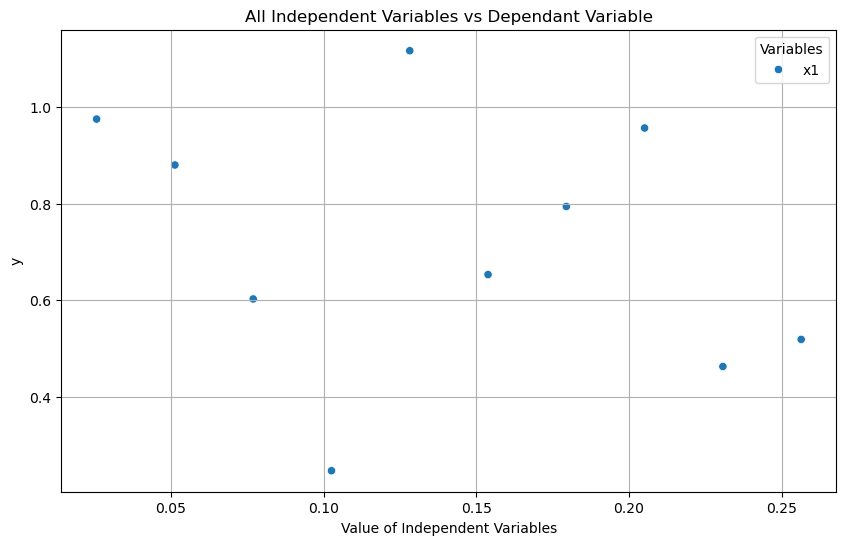

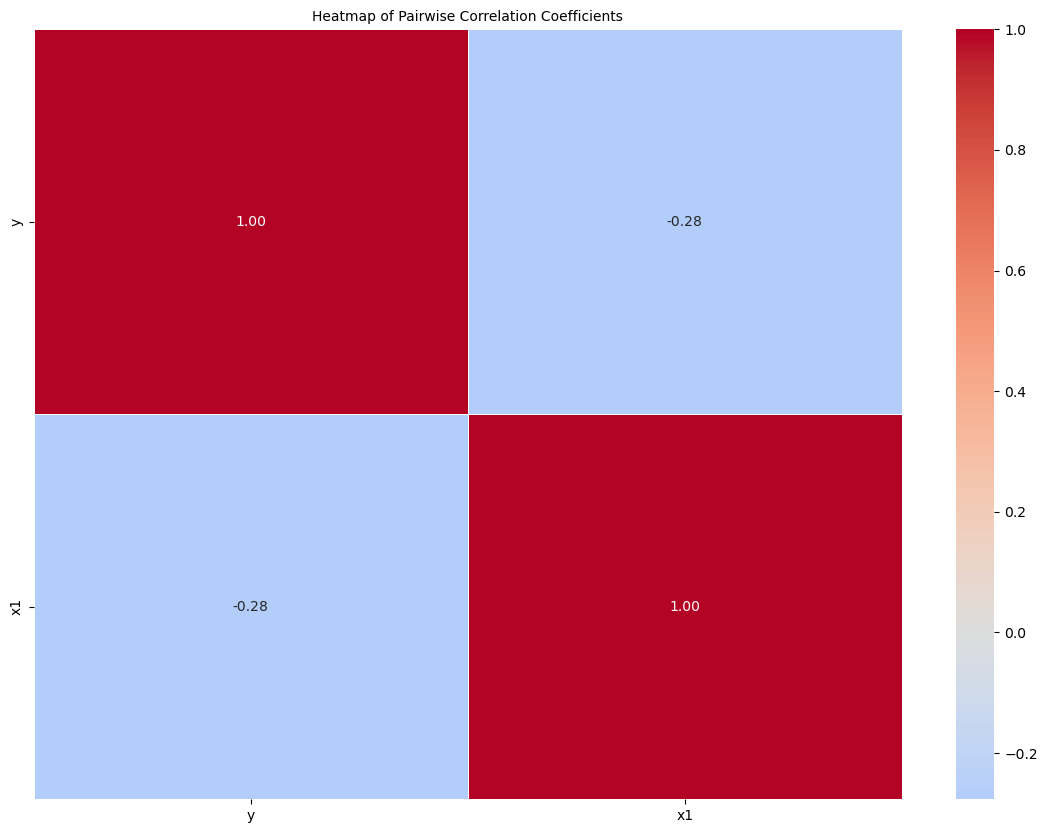

     feature       VIF
1  intercept  4.666667
0         x1  1.000000
--------------------------------------------------

All remaining features have VIF below threshold of 5.0.
------------------- progressive_vif_analysis ------------------------------
ALGORITHM Linear Regression
Total dropped features are [] 
Metrics History
 Empty DataFrame
Columns: []
Index: []
------------------- progressive_vif_analysis ------------------------------

All remaining features have VIF below threshold of 5.0.
------------------- progressive_vif_analysis ------------------------------
ALGORITHM SVM Regression
Total dropped features are [] 
Metrics History
 Empty DataFrame
Columns: []
Index: []
------------------- progressive_vif_analysis ------------------------------

All remaining features have VIF below threshold of 5.0.
------------------- progressive_vif_analysis ------------------------------
ALGORITHM RandomForest
Total dropped features are [] 
Metrics History
 Empty DataFrame
Columns: []
Index

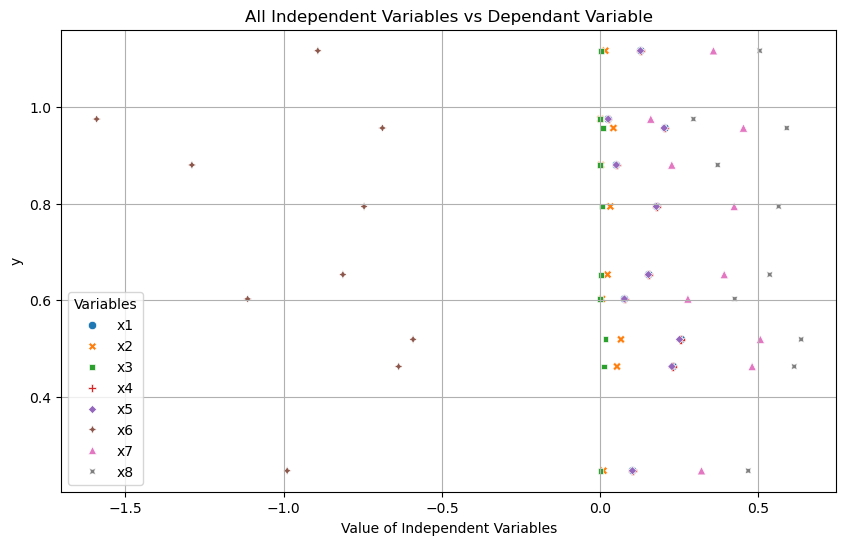

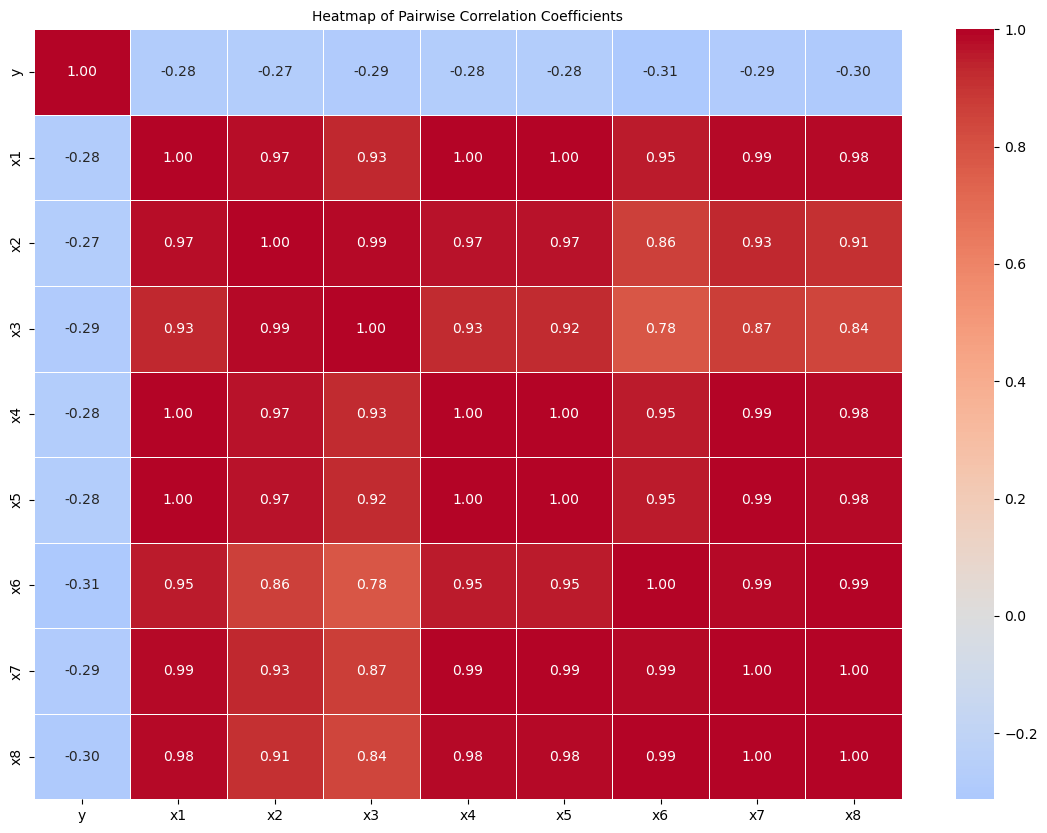

c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


     feature           VIF
0         x1           inf
3         x4           inf
4         x5           inf
2         x3  8.188363e+14
8  intercept  3.373483e+13
6         x7  8.394408e+12
7         x8  8.042142e+12
5         x6  1.933954e+11
1         x2  9.583860e+10
--------------------------------------------------
Dropping 'x1' (VIF: inf)
Dropping 'x4' (VIF: 230953827044640.81)
Dropping 'x7' (VIF: 326040659333.27)
Dropping 'x8' (VIF: 12577953.82)
Dropping 'x2' (VIF: 18657.78)
Dropping 'x5' (VIF: 98.36)

All remaining features have VIF below threshold of 5.0.
------------------- progressive_vif_analysis ------------------------------
ALGORITHM Linear Regression
Total dropped features are ['x1', 'x4', 'x7', 'x8', 'x2', 'x5'] 
Metrics History
     R-squared Train    RMSE Train  R-squared Test  RMSE Test
x1         1.000000  8.217418e-13  -306639.918859  39.166078
x4         1.000000  1.136237e-12  -303434.276056  38.960818
x7         1.000000  2.351523e-12  -311393.513462  39.468490


c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Dropping 'x1' (VIF: inf)
Dropping 'x4' (VIF: 230953827044640.81)
Dropping 'x7' (VIF: 326040659333.27)
Dropping 'x8' (VIF: 12577953.82)
Dropping 'x2' (VIF: 18657.78)
Dropping 'x5' (VIF: 98.36)

All remaining features have VIF below threshold of 5.0.
------------------- progressive_vif_analysis ------------------------------
ALGORITHM RandomForest
Total dropped features are ['x1', 'x4', 'x7', 'x8', 'x2', 'x5'] 
Metrics History
     R-squared Train  RMSE Train  R-squared Test  RMSE Test
x1         0.826819    0.092068      -53.518824   0.522238
x4         0.823279    0.093005      -51.831128   0.514091
x7         0.825898    0.092313      -57.227866   0.539710
x8         0.827964    0.091764      -57.767431   0.542205
x2         0.823860    0.092852      -55.952069   0.533765
x5         0.826047    0.092273      -57.980036   0.543185
------------------- progressive_vif_analysis ------------------------------
Dropping 'x1' (VIF: inf)


c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Dropping 'x4' (VIF: 230953827044640.81)
Dropping 'x7' (VIF: 326040659333.27)
Dropping 'x8' (VIF: 12577953.82)
Dropping 'x2' (VIF: 18657.78)
Dropping 'x5' (VIF: 98.36)

All remaining features have VIF below threshold of 5.0.
------------------- progressive_vif_analysis ------------------------------
ALGORITHM XGBoost
Total dropped features are ['x1', 'x4', 'x7', 'x8', 'x2', 'x5'] 
Metrics History
     R-squared Train  RMSE Train  R-squared Test  RMSE Test
x1              1.0    0.000006      -38.065107   0.442068
x4              1.0    0.000006      -49.480788   0.502525
x7              1.0    0.000006      -51.606933   0.512999
x8              1.0    0.000006      -51.400918   0.511994
x2              1.0    0.000006      -48.263790   0.496431
x5              1.0    0.000006      -69.975082   0.595865
------------------- progressive_vif_analysis ------------------------------
Dropping 'x1' (VIF: inf)
Dropping 'x4' (VIF: 230953827044640.81)
Dropping 'x7' (VIF: 326040659333.27)


c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Dropping 'x8' (VIF: 12577953.82)
Dropping 'x2' (VIF: 18657.78)
Dropping 'x5' (VIF: 98.36)

All remaining features have VIF below threshold of 5.0.
------------------- progressive_vif_analysis ------------------------------
ALGORITHM knn
Total dropped features are ['x1', 'x4', 'x7', 'x8', 'x2', 'x5'] 
Metrics History
     R-squared Train  RMSE Train  R-squared Test  RMSE Test
x1        -0.050128    0.226716      -31.191001   0.401294
x4        -0.050128    0.226716      -31.191001   0.401294
x7        -0.050128    0.226716      -31.191001   0.401294
x8        -0.050128    0.226716      -31.191001   0.401294
x2        -0.050128    0.226716      -31.191001   0.401294
x5        -0.050128    0.226716      -31.191001   0.401294
------------------- progressive_vif_analysis ------------------------------
Dropping 'x1' (VIF: inf)
Dropping 'x4' (VIF: 230953827044640.81)
Dropping 'x7' (VIF: 326040659333.27)


c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Dropping 'x8' (VIF: 12577953.82)
Dropping 'x2' (VIF: 18657.78)
Dropping 'x5' (VIF: 98.36)

All remaining features have VIF below threshold of 5.0.
------------------- progressive_vif_analysis ------------------------------
ALGORITHM Neural Network-10
Total dropped features are ['x1', 'x4', 'x7', 'x8', 'x2', 'x5'] 
Metrics History
     R-squared Train  RMSE Train  R-squared Test  RMSE Test
x1         0.105843    0.209203      -41.322803   0.460132
x4        -0.078666    0.229776      -41.630875   0.461803
x7         0.193351    0.198702      -44.900011   0.479183
x8        -0.456294    0.266984      -26.087826   0.368114
x2         0.111889    0.208494      -56.251690   0.535167
x5         0.099960    0.209890      -45.711613   0.483401
------------------- progressive_vif_analysis ------------------------------
Metrics Sheet2

                   R-squared Train  RMSE Train  R-squared Test  RMSE Test
Linear Regression         0.320891    0.182318     -172.531724   0.931718
SVM Regression

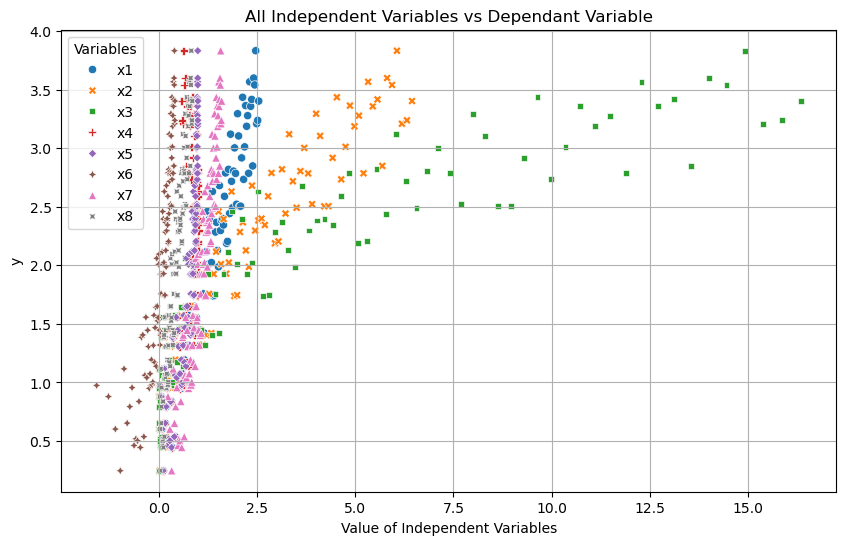

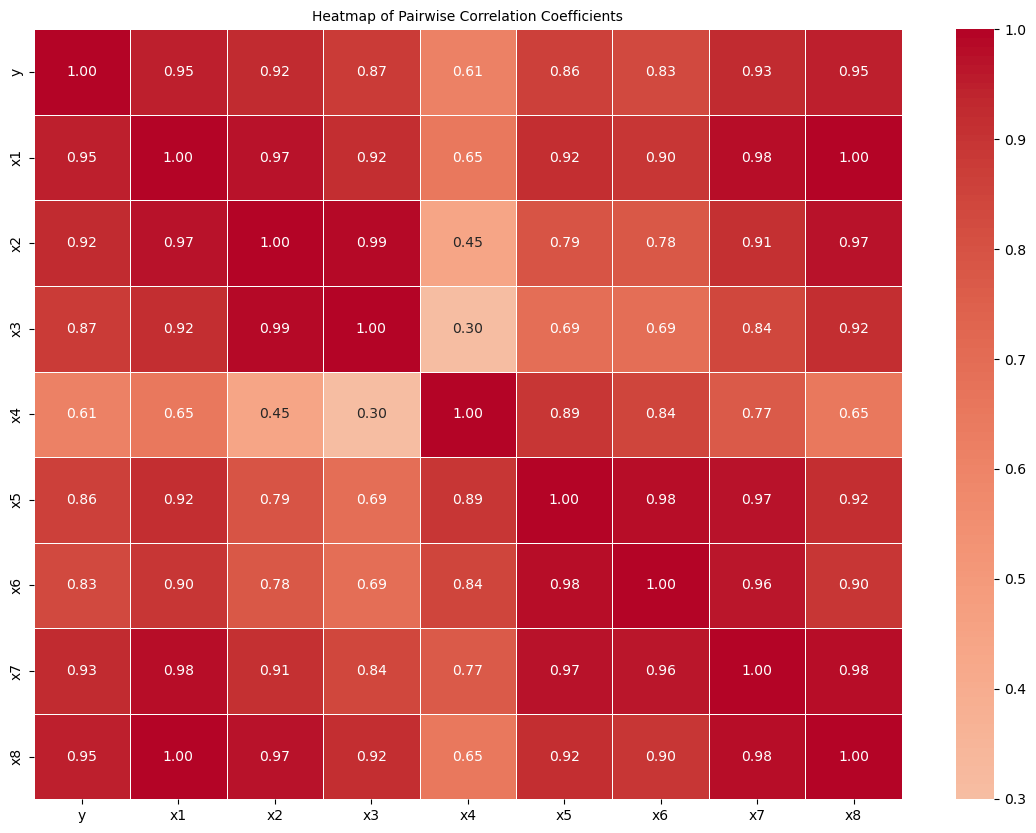

c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


     feature           VIF
0         x1           inf
7         x8           inf
1         x2  1.166248e+07
6         x7  7.996571e+05
8  intercept  7.946015e+05
2         x3  7.298874e+05
4         x5  2.554343e+05
3         x4  8.281459e+04
5         x6  2.083295e+04
--------------------------------------------------
Dropping 'x1' (VIF: inf)
Dropping 'x8' (VIF: 54531135.00)
Dropping 'x7' (VIF: 57013.84)
Dropping 'x3' (VIF: 8076.97)
Dropping 'x5' (VIF: 268.95)
Dropping 'x6' (VIF: 15.91)

All remaining features have VIF below threshold of 5.0.
------------------- progressive_vif_analysis ------------------------------
ALGORITHM Linear Regression
Total dropped features are ['x1', 'x8', 'x7', 'x3', 'x5', 'x6'] 
Metrics History
     R-squared Train  RMSE Train  R-squared Test  RMSE Test
x1         0.900276    0.267826        0.917476   0.286130
x8         0.898980    0.269561        0.912908   0.293942
x7         0.898946    0.269606        0.915074   0.290264
x3         0.897800    0.271

c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping 'x1' (VIF: inf)
Dropping 'x8' (VIF: 54531135.00)
Dropping 'x7' (VIF: 57013.84)
Dropping 'x3' (VIF: 8076.97)
Dropping 'x5' (VIF: 268.95)
Dropping 'x6' (VIF: 15.91)

All remaining features have VIF below threshold of 5.0.
------------------- progressive_vif_analysis ------------------------------
ALGORITHM SVM Regression
Total dropped features are ['x1', 'x8', 'x7', 'x3', 'x5', 'x6'] 
Metrics History
     R-squared Train  RMSE Train  R-squared Test  RMSE Test
x1         0.751531    0.422755        0.695315   0.549792
x8         0.752023    0.422336        0.695938   0.549229
x7         0.736798    0.435108        0.676676   0.566358
x3         0.872986    0.302259        0.872949   0.355027
x5         0.866632    0.309726        0.866043   0.364548
x6         0.870631    0.305048        0.872933   0.355049
------------------- progressive_vif_analysis ------------------------------
Dropping 'x1' (VIF: inf)
Dropping 'x8' (VIF: 54531135.00)
Dropping 'x7' (VIF: 57013.84)
Dropping 'x

c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping 'x8' (VIF: 54531135.00)
Dropping 'x7' (VIF: 57013.84)
Dropping 'x3' (VIF: 8076.97)
Dropping 'x5' (VIF: 268.95)
Dropping 'x6' (VIF: 15.91)

All remaining features have VIF below threshold of 5.0.
------------------- progressive_vif_analysis ------------------------------
ALGORITHM XGBoost
Total dropped features are ['x1', 'x8', 'x7', 'x3', 'x5', 'x6'] 
Metrics History
     R-squared Train  RMSE Train  R-squared Test  RMSE Test
x1         0.990341    0.083351        0.904180   0.308320
x8         0.990341    0.083351        0.910921   0.297276
x7         0.990341    0.083351        0.907905   0.302267
x3         0.990341    0.083351        0.904083   0.308476
x5         0.990341    0.083351        0.914865   0.290620
x6         0.990341    0.083351        0.908332   0.301565
------------------- progressive_vif_analysis ------------------------------
Dropping 'x1' (VIF: inf)


c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping 'x8' (VIF: 54531135.00)
Dropping 'x7' (VIF: 57013.84)
Dropping 'x3' (VIF: 8076.97)
Dropping 'x5' (VIF: 268.95)
Dropping 'x6' (VIF: 15.91)

All remaining features have VIF below threshold of 5.0.
------------------- progressive_vif_analysis ------------------------------
ALGORITHM knn
Total dropped features are ['x1', 'x8', 'x7', 'x3', 'x5', 'x6'] 
Metrics History
     R-squared Train  RMSE Train  R-squared Test  RMSE Test
x1         0.894967    0.274863        0.911382   0.296506
x8         0.894967    0.274863        0.911382   0.296506
x7         0.894967    0.274863        0.911382   0.296506
x3         0.895018    0.274796        0.911382   0.296506
x5         0.894963    0.274867        0.911382   0.296506
x6         0.893789    0.276400        0.912348   0.294885
------------------- progressive_vif_analysis ------------------------------
Dropping 'x1' (VIF: inf)
Dropping 'x8' (VIF: 54531135.00)


c:\Users\SUSHANT\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping 'x7' (VIF: 57013.84)
Dropping 'x3' (VIF: 8076.97)
Dropping 'x5' (VIF: 268.95)
Dropping 'x6' (VIF: 15.91)

All remaining features have VIF below threshold of 5.0.
------------------- progressive_vif_analysis ------------------------------
ALGORITHM Neural Network-10
Total dropped features are ['x1', 'x8', 'x7', 'x3', 'x5', 'x6'] 
Metrics History
     R-squared Train  RMSE Train  R-squared Test  RMSE Test
x1         0.885937    0.286434        0.907237   0.303362
x8         0.814606    0.365174        0.906711   0.304220
x7         0.860490    0.316778        0.890797   0.329147
x3         0.853050    0.325116        0.864381   0.366803
x5         0.866120    0.310320        0.909595   0.299480
x6         0.856677    0.321078        0.848038   0.388275
------------------- progressive_vif_analysis ------------------------------
Metrics Sheet3

                   R-squared Train  RMSE Train  R-squared Test  RMSE Test
Linear Regression         0.896627    0.272682        0.919219  

In [6]:
for sheet_name in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    X = df.drop(columns=['y'])
    # Note: VIF analysis requires a constant/intercept term to be included
    X['intercept'] = 1
    y = df['y']
    target_var = 'y'
    independent_vars = [col for col in df.columns if col != target_var]

    # --- Reshape the DataFrame into "long" format ---
    # We use melt() to stack the independent variables into a single 'X_Value' column,
    # while keeping the 'y' value repeated for each entry.
    df_long = df.melt(
        id_vars=[target_var],
        value_vars=independent_vars,
        var_name='Independent_Variable',
        value_name='X_Value'
    )

    # --- Create the single scatter plot using Seaborn ---
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df_long,
        x='X_Value',          # All X values combined here
        y=target_var,         # The common Y value
        hue='Independent_Variable', # Differentiate variables by color
        style='Independent_Variable' # Differentiate variables by marker shape
    )

    plt.title('All Independent Variables vs Dependant Variable')
    plt.xlabel('Value of Independent Variables')
    plt.ylabel(target_var)
    plt.legend(title='Variables')
    plt.grid(True)
    plt.show()
    
    # b. Heatmap
    corr = df.select_dtypes(include='number').corr()

    plt.figure(figsize=(14, 10))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
    plt.title('Heatmap of Pairwise Correlation Coefficients', fontsize=10)
    plt.show()
    
    # Run the function
    vif_results = calculate_vif(X)
    # Display results, sorting by VIF value for easier observation
    print(vif_results.sort_values(by='VIF', ascending=False))
    print('-'*50)
    for model_name, algorithm in algorithms.items():
        trainX, testX, trainy, testy,r2_train,rmse_train,r2_test,rmse_test = trainAndTestWithSampling(X,y,False,False,algorithm, model_name)

        # Work on a copy of the training data
        X_current = trainX.copy()
        X_test_current = testX.copy()
        progressive_vif_analysis(X_current, X_test_current, trainy, testy, algorithm, model_name)

    # Display the metrics' Tables
    print(f"Metrics {sheet_name}\n")
    print(metric_table.to_string())
    print("-------------------------------------------------")
    

## PCA Program Starting Here!

In [7]:

def train_and_evaluate_with_pca(X,y,n_pcs_list):
    # Ensure X only contains the features you want to analyze with PCA

    # --- PCA Process ---
    pca_results = pd.DataFrame(columns=['Model', 'Features', 'R² Train', 'R² Test', 'RMSE Train', 'RMSE Test'])
    # Step 1: Standardize the data
    # PCA is affected by scale, so standardization (mean=0, variance=1) is crucial.
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Step 2: Perform PCA
    # We use all components initially to analyze total variance contribution
    pca = PCA(n_components=None) # None keeps all original dimensions as PCs
    pca.fit(X_scaled)

    # Step 3: Extract explained variance ratios
    # The explained_variance_ratio_ attribute provides the percentage of variance 
    # explained by each individual principal component.
    explained_variance = pca.explained_variance_ratio_

    # --- Plotting the Contributions (Bar Chart) ---

    plt.figure(figsize=(10, 6))

    # Create labels for the X-axis (PC1, PC2, PC3, ...)
    pc_labels = [f"PC{i+1}" for i in range(len(explained_variance))]

    # Plotting the bar chart
    plt.bar(pc_labels, explained_variance * 100, color='skyblue', edgecolor='black')

    # Adding labels and title
    plt.xlabel('Principal Component')
    plt.ylabel('Percentage of Explained Variance (%)')
    plt.title('Contribution of Each Principal Component to Total Variance')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--')

    # # Optional: Add cumulative variance line (scree plot element)
    # cumulative_variance = np.cumsum(explained_variance) * 100
    # plt.plot(pc_labels, cumulative_variance, color='red', linestyle='--', marker='o', label='Cumulative Variance (%)')
    # plt.legend()

    # plt.show()

    # # --- Interpretation ---
    # print("\nCumulative Variance Explained:")
    # for i, cum_var in enumerate(cumulative_variance):
    #     print(f"PC{i+1}: {cum_var:.2f}%")

    # You can now select a subset of components (e.g., those explaining 95% variance)
    # and use them as your new, uncorrelated independent variables in your model.
    # Example: Transform data retaining 95% variance
    for n_pcs in n_pcs_list:
        pca_n = PCA()
        X_pca = pca_n.fit_transform(X_scaled)
        X_pca_subset = X_pca[:, :n_pcs]  # Select the first `n_pcs` PCs
        print(f"\nUsing top {n_pcs} principal components:")
        print(f"Original dimensions: {X_scaled.shape[1]}")
        print(f"Reduced dimensions: {X_pca_subset.shape[1]}")
        np.random.seed(5)
        # split into train/test sets with same class ratio
        trainX, testX, trainy, testy = model_selection.train_test_split(X_pca_subset, y, test_size=0.2,random_state=42)

        for model_name, model in algorithms.items():
            # Train the model
            model.fit(trainX, trainy)

            # Evaluate on train set
            y_train_pred = model.predict(trainX)
            r2_train = metrics.r2_score(trainy, y_train_pred)
            rmse_train = np.sqrt(metrics.mean_squared_error(trainy, y_train_pred))

            # Evaluate on test set
            y_test_pred = model.predict(testX)
            r2_test = metrics.r2_score(testy, y_test_pred)
            rmse_test = np.sqrt(metrics.mean_squared_error(testy, y_test_pred))

            # Store results
            pca_results.loc[len(pca_results)] = {
                'Model': model_name,
                'Features': f'{n_pcs} PCs',
                'R² Train': r2_train,
                'R² Test': r2_test,
                'RMSE Train': rmse_train,
                'RMSE Test': rmse_test
            }
     # Train and evaluate models using original features
    trainX, testX, trainy, testy = model_selection.train_test_split(X, y, test_size=0.2, random_state=42)
    for model_name, model in algorithms.items():
        model.fit(trainX, trainy)

        # Evaluate on train set
        y_train_pred = model.predict(trainX)
        r2_train = metrics.r2_score(trainy, y_train_pred)
        rmse_train = np.sqrt(metrics.mean_squared_error(trainy, y_train_pred))

        # Evaluate on test set
        y_test_pred = model.predict(testX)
        r2_test = metrics.r2_score(testy, y_test_pred)
        rmse_test = np.sqrt(metrics.mean_squared_error(testy, y_test_pred))

        # Store results
        pca_results.loc[len(pca_results)] = {
            'Model': model_name,
            'Features': 'Original Features',
            'R² Train': r2_train,
            'R² Test': r2_test,
            'RMSE Train': rmse_train,
            'RMSE Test': rmse_test
        }

    return pca_results
    

------------------ Sheet1 -------------------------------

Using top 3 principal components:
Original dimensions: 1
Reduced dimensions: 1

Using top 5 principal components:
Original dimensions: 1
Reduced dimensions: 1
                Model           Features  R² Train   R² Test  RMSE Train  \
0   Linear Regression              3 PCs  0.010233  0.219716    0.264268   
1      SVM Regression              3 PCs  0.107932  0.364003    0.250886   
2        RandomForest              3 PCs  0.625460  0.677888    0.162565   
3             XGBoost              3 PCs  0.999994  0.860441    0.000658   
4                 knn              3 PCs -0.017185 -0.666252    0.267903   
5   Neural Network-10              3 PCs -0.252500 -0.152291    0.297281   
6   Linear Regression              5 PCs  0.010233  0.219716    0.264268   
7      SVM Regression              5 PCs  0.107932  0.364003    0.250886   
8        RandomForest              5 PCs  0.625460  0.677888    0.162565   
9             XGBoost 

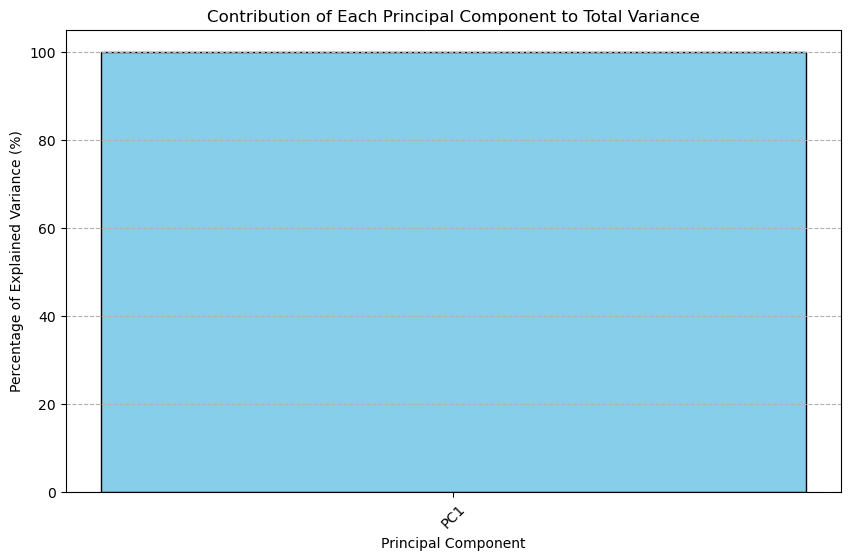

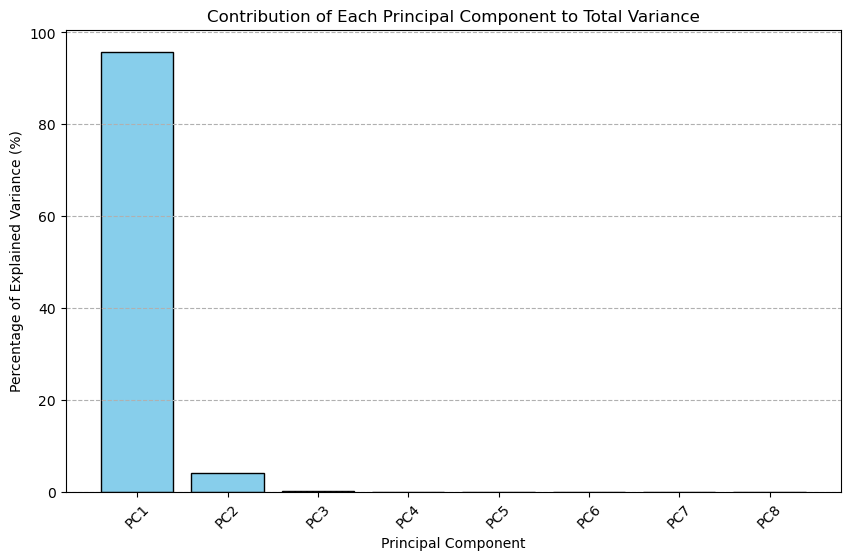

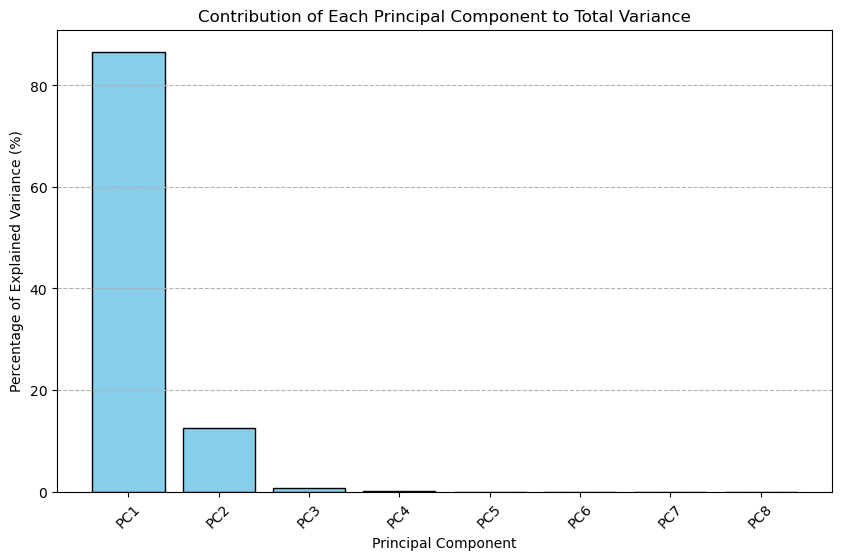

In [8]:
n_pcs_list = [3, 5]

for sheet_name in xls.sheet_names:
    print(f"------------------ {sheet_name} -------------------------------")
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    X = df.drop(columns=['y'])
    y = df['y']
    pca_results = train_and_evaluate_with_pca(X,y, n_pcs_list=n_pcs_list)
    # Display results
    print(pca_results)
    print("----------------------------------------------------------------\n\n")